In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Data/CFW_Police_Crime_2005.csv')

/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_49036/3531213309.py:1: DtypeWarning: Columns (1,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('CFW_Police_Crime_2005.csv')


In [3]:
df.head()

,Case_No_Offense,Case_No,Reported_Date,Nature_Of_Call,From_Date,Offense,Offense_Desc,BLOCK_ADDRESS,City,State,Beat,Division,CouncilDistrict,Attempt_Complete,Location_Type,LocationTypeDescription,intTotal,Location_1,ObjectId
0,050060341-13C,50060341,2005-05-21T09:00:00,ASSAULT C,2005-05-21T09:00:00,13C,PC 22.01(A)(2) Assault by threat NonFamily Member,4800 E BERRY ST,FORT WORTH,TX,NaN,NaN,NaN,A,20,20 RESIDENCE/HOME,0,"(32.712824781814604, -97.251662402605788)",1
1,050076783-13B,50076783,2005-06-28T05:58:00,ASSAULT,2005-06-27T19:45:00,13B,PC 22.01(A)(1) Assault Causes Bodily Injury,700 E BERRY ST,FORT WORTH,TX,NaN,NaN,NaN,A,13,13 HIGHWAY/ROAD/ALLEY,0,"(32.705870521625776, -97.320234343317281)",2
2,050060400-23H,50060400,2005-05-21T08:00:00,THEFT,2005-05-16T15:00:00,23H,PC 31.03 - Others Theft - Others,3500 FRAZIER CT,FORT WORTH,TX,NaN,NaN,NaN,A,20,20 RESIDENCE/HOME,0,"(32.811814603188182, -97.130512907809305)",3
3,050060410-90E,50060410,2005-05-21T14:41:00,PUBLICINTO,2005-05-21T14:41:00,90E,PC 49.02 Public Intoxication,8700 RANDOL MILL RD,FORT WORTH,TX,NaN,NaN,NaN,A,18,18 PARKING LOT/GARAGE,0,"(32.765809857394068, -97.165077188964332)",4
4,050076788-90Z,50076788,2005-06-28T15:49:00,INDECEXPOS,2005-06-25T16:00:00,90Z,PC 22.011 Sexual Assault,13700 PINNACLE CIR E,FORT WORTH,TX,NaN,NaN,NaN,A,20,20 RESIDENCE/HOME,0,"(32.81635007631882, -97.069120326401631)",5


In [5]:
df["Reported_Date"].dtype
df["Reported_Date"].isna().sum()

2

In [6]:
len(df)

1414787

In [7]:
df.dropna(subset=['Reported_Date'], inplace=True)
print(len(df))

1414785


In [8]:
df['Date'] = pd.to_datetime(df['Reported_Date'], errors='coerce')

In [9]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

0

## Monthly Grouping

In [19]:
df2 = (
    df.resample('M', on='Date')
      .size()
      .reset_index(name='Crime_Count')
)


/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_49036/322491763.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', on='Date')


In [20]:
df2.head(10)

,Date,Crime_Count
0,1971-11-30,1
1,1971-12-31,0
2,1972-01-31,0
3,1972-02-29,0
4,1972-03-31,0
5,1972-04-30,0
6,1972-05-31,0
7,1972-06-30,0
8,1972-07-31,2
9,1972-08-31,0


#### The data is good only after 2005 August, so starting from 2006

In [42]:
df2[(df2['Date'] >= '2006-01-01')].head(10)

,Date,Crime_Count
410,2006-01-01,6665
411,2006-02-01,5683
412,2006-03-01,6903
413,2006-04-01,7005
414,2006-05-01,7090
415,2006-06-01,7328
416,2006-07-01,7818
417,2006-08-01,7567
418,2006-09-01,7258
419,2006-10-01,7443


In [36]:
df2[(df2['Date'] >= '2006-01-01')].__len__()

239

In [37]:
df2['Date'] = df2['Date'].dt.to_period('M').dt.to_timestamp()

In [41]:
df2.head()

,Date,Crime_Count
0,1971-11-01,1
1,1971-12-01,0
2,1972-01-01,0
3,1972-02-01,0
4,1972-03-01,0


In [39]:
df2.tail()

,Date,Crime_Count
644,2025-07-01,4914
645,2025-08-01,4971
646,2025-09-01,4801
647,2025-10-01,5000
648,2025-11-01,4440


In [43]:
## Filtering data from 2006 
df2 = df2[(df2['Date'] >= '2006-01-01')]
df2.head()

,Date,Crime_Count
410,2006-01-01,6665
411,2006-02-01,5683
412,2006-03-01,6903
413,2006-04-01,7005
414,2006-05-01,7090


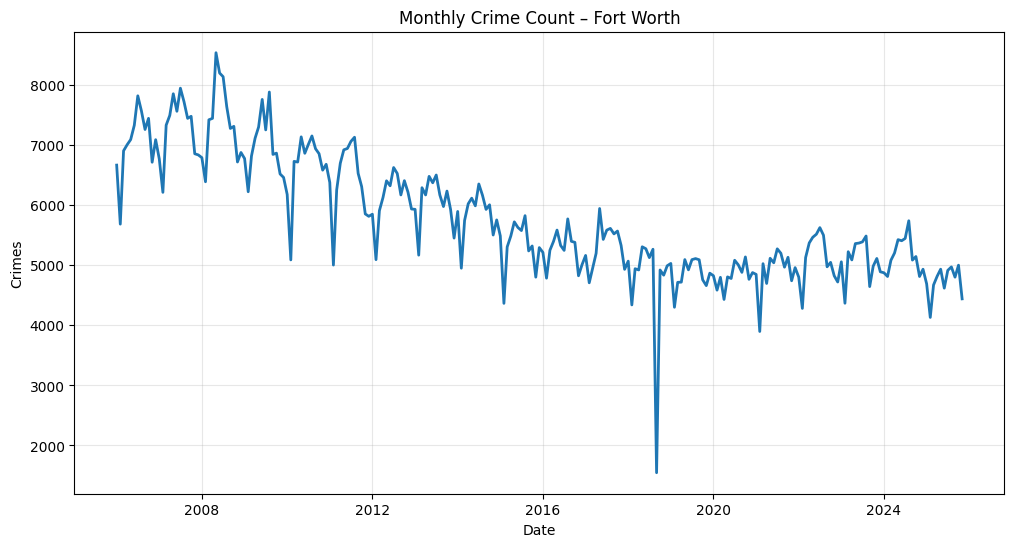

In [44]:
plt.figure(figsize=(12,6))
plt.plot(df2['Date'], df2['Crime_Count'], linewidth=2)

plt.title('Monthly Crime Count – Fort Worth')
plt.xlabel('Date')
plt.ylabel('Crimes')
plt.grid(alpha=0.3)
plt.show()

In [46]:
## Fixing the dip in 2018
df2.loc[(df2['Date'].dt.year == 2018) &
        (df2['Date'].dt.month.isin([9])), 'Crime_Count'] = np.nan
df2['Crime_Count'] = df2['Crime_Count'].interpolate(method='linear')

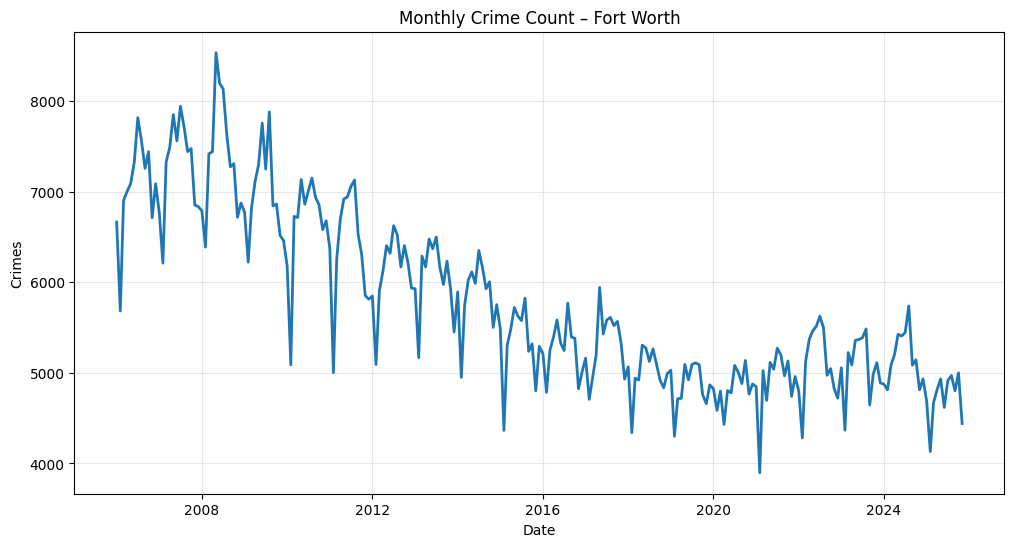

In [47]:
plt.figure(figsize=(12,6))
plt.plot(df2['Date'], df2['Crime_Count'], linewidth=2)

plt.title('Monthly Crime Count – Fort Worth')
plt.xlabel('Date')
plt.ylabel('Crimes')
plt.grid(alpha=0.3)
plt.show()

In [48]:
df2.to_csv('Monthly_Cleaned_2006.csv', index=False)

In [49]:
from pmdarima.arima.utils import ndiffs, nsdiffs

y = df2['Crime_Count']

# Regular differencing (ADF / KPSS)
d_adf = ndiffs(y, test='adf')
d_kpss = ndiffs(y, test='kpss')
d_pp   = ndiffs(y, test='pp')

print("Recommended d (ADF):", d_adf)
print("Recommended d (KPSS):", d_kpss)
print("Recommended d (PP):", d_pp)

# Seasonal differencing (OCSB test)
D = nsdiffs(y, m=12, test='ch')
print("Recommended D:", D)

Recommended d (ADF): 0
Recommended d (KPSS): 1
Recommended d (PP): 0
Recommended D: 0


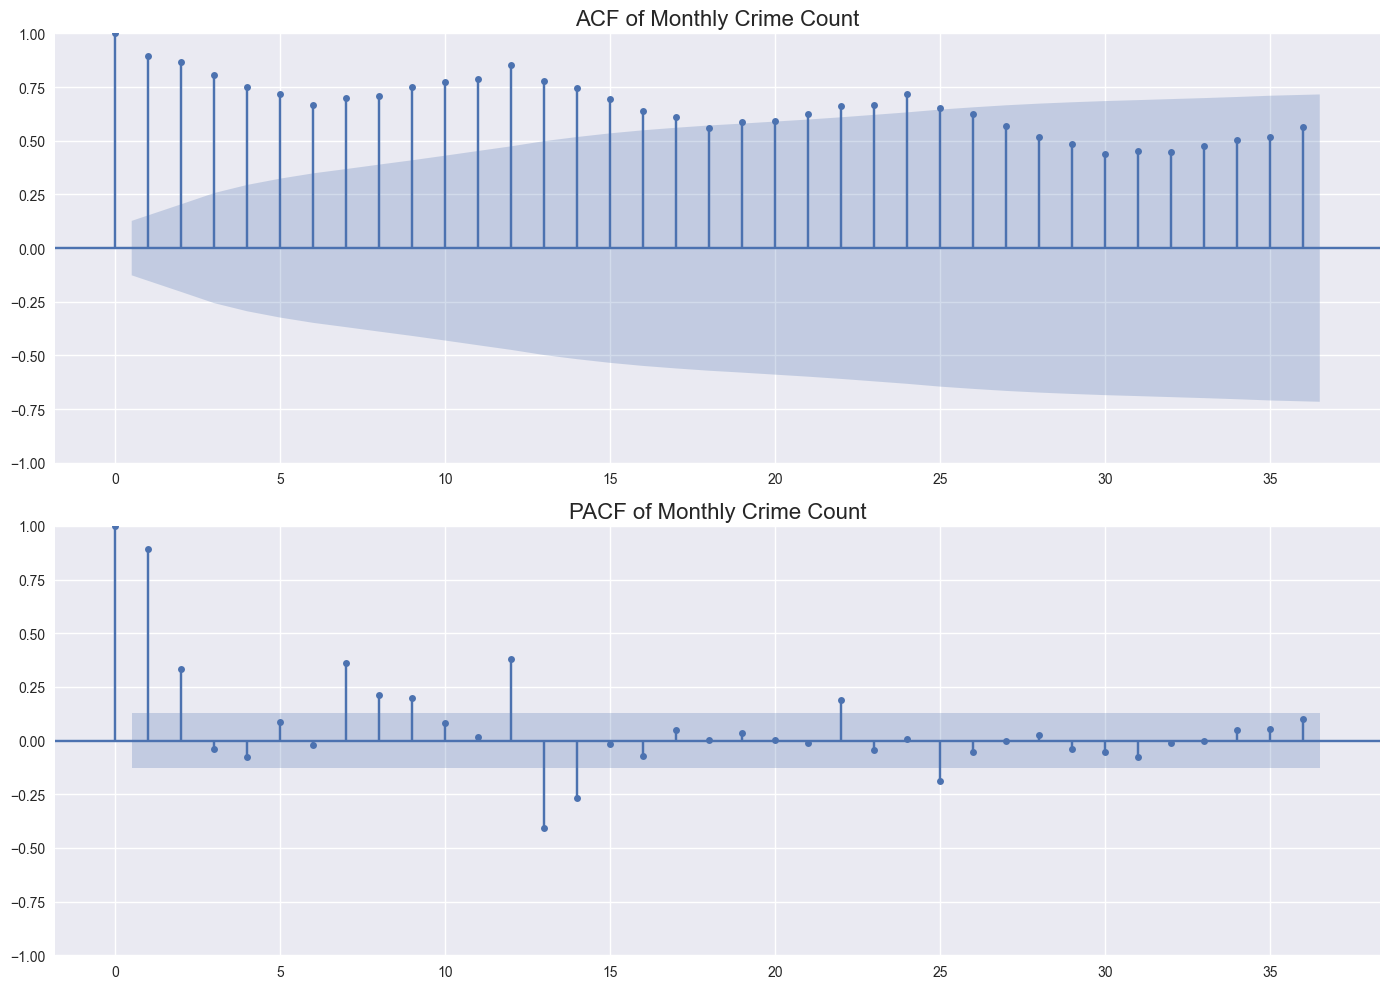

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots(2, 1, figsize=(14,10))

# ACF
plot_acf(y, ax=ax[0], lags=36)       # 3 years worth of lags
ax[0].set_title("ACF of Monthly Crime Count", fontsize=16)

# PACF
plot_pacf(y, ax=ax[1], lags=36, method='ywm') 
ax[1].set_title("PACF of Monthly Crime Count", fontsize=16)

plt.tight_layout()
plt.show()

In [51]:
import pmdarima as pm

auto_model = pm.auto_arima(
    y,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None,              # let it find d
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    D=None,              # let it find D (or set D=1 if you want to force)
    m=12,                # monthly seasonality
    seasonal=True,
    stepwise=True,
    trace=True,          # prints the tried models
    information_criterion='aicc',
    error_action='ignore',
    suppress_warnings=True
)

print(auto_model.summary())
print("Selected (p,d,q):", auto_model.order)
print("Selected (P,D,Q,m):", auto_model.seasonal_order)

Performing stepwise search to minimize aicc
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AICC=3572.853, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AICC=3364.454, Time=0.65 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AICC=3447.280, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AICC=3570.930, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AICC=3538.739, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AICC=3353.110, Time=0.48 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AICC=3343.780, Time=1.20 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AICC=3324.359, Time=0.55 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AICC=3441.409, Time=0.15 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AICC=3329.203, Time=1.53 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AICC=3408.952, Time=0.95 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AICC=inf, Time=1.91 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AICC=3361.572, Time=0.28 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AICC=3321.202, Time=0.63 sec
 ARIMA(2,

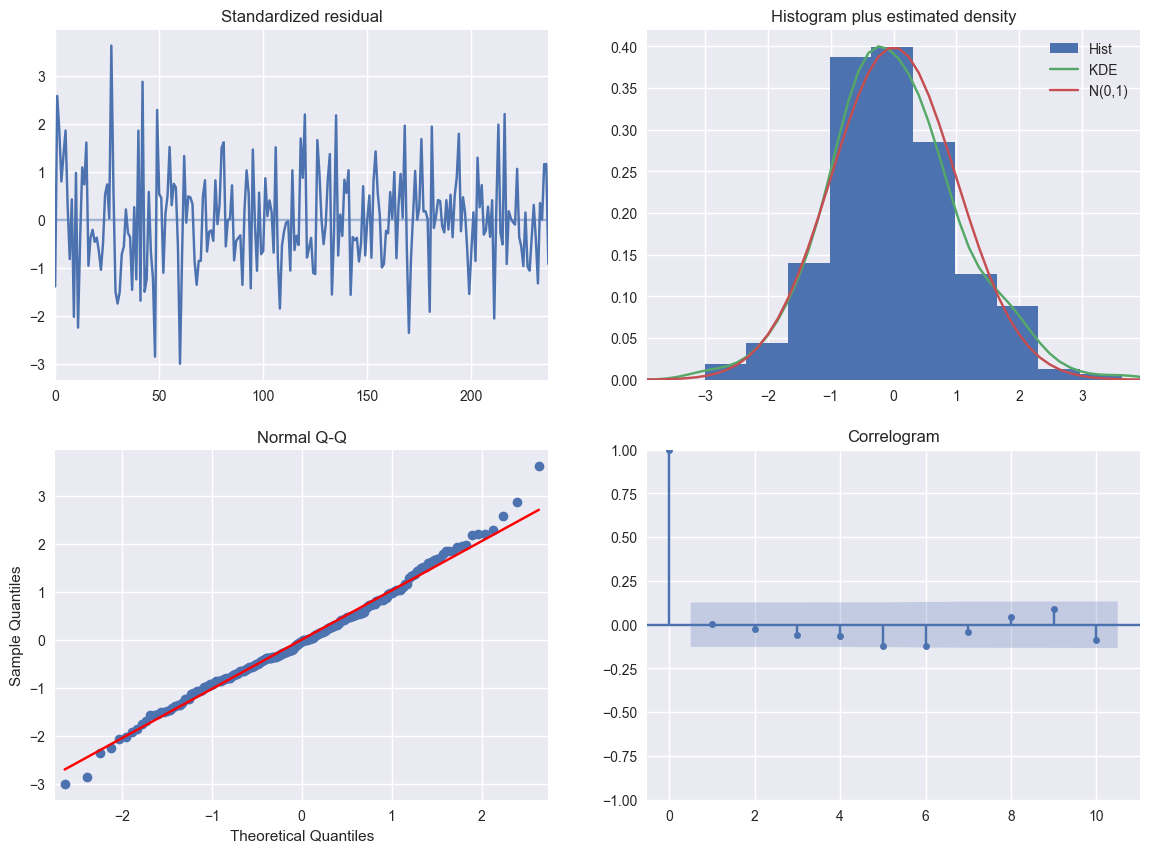

In [53]:
auto_model.plot_diagnostics(figsize=(14,10))
plt.show()

In [54]:
print(auto_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  239
Model:             SARIMAX(3, 1, 0)x(2, 0, [1], 12)   Log Likelihood               -1650.980
Date:                              Thu, 04 Dec 2025   AIC                           3317.960
Time:                                      19:36:44   BIC                           3345.738
Sample:                                           0   HQIC                          3329.155
                                              - 239                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.8104      1.018     -0.796      0.426      -2.806       1.185
ar.L1         -0.47

### Applying Log/boxcox on the data

In [55]:
df2['Crime_Count_Log'] = np.log(df2['Crime_Count'])

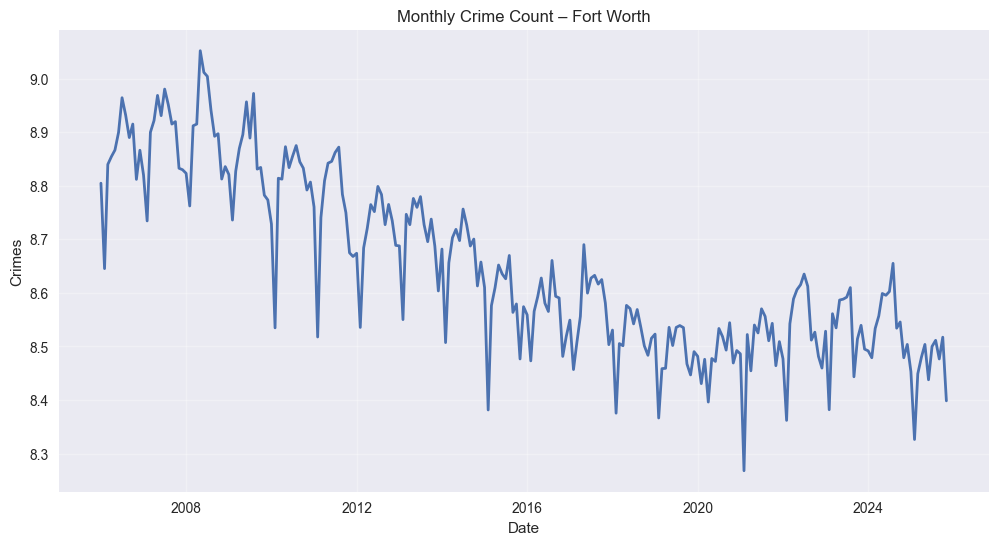

In [56]:
plt.figure(figsize=(12,6))
plt.plot(df2['Date'], df2['Crime_Count_Log'], linewidth=2)

plt.title('Monthly Crime Count – Fort Worth')
plt.xlabel('Date')
plt.ylabel('Crimes')
plt.grid(alpha=0.3)
plt.show()

### Applying BoxCox

In [57]:
from scipy.stats import boxcox
df2['Crime_Count_BoxCox'], fitted_lambda = boxcox(df2['Crime_Count'])
print("Fitted Box-Cox Lambda:", fitted_lambda)

Fitted Box-Cox Lambda: -1.1836101207315617


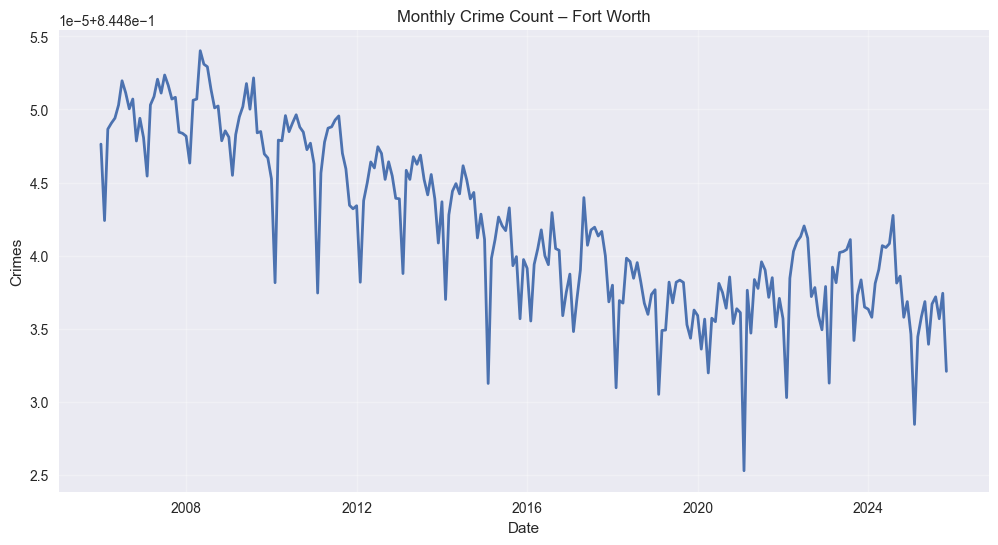

In [58]:
plt.figure(figsize=(12,6))
plt.plot(df2['Date'], df2['Crime_Count_BoxCox'], linewidth=2)

plt.title('Monthly Crime Count – Fort Worth')
plt.xlabel('Date')
plt.ylabel('Crimes')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA(2,0,1)(0,1,0)[12]
model_manual = SARIMAX(
    y,
    # order=(1, 0, 2), # 1210
    # order=(1, 0, 1), # 1222
    # order=(2, 0, 2), # 1212
    # order=(2, 1, 2), # 1201
    # order=(2, 1, 1), # 1212
    # order=(2, 1, 2), # 1201
    # seasonal_order=(0, 1, 1, 12),
    order=(0, 1, 2),
    seasonal_order=(0, 1, 2, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_manual = model_manual.fit()

In [61]:
y = df2['Crime_Count_BoxCox']
auto_model = pm.auto_arima(
    y,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None,              # let it find d
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    D=None,              # let it find D (or set D=1 if you want to force)
    m=12,                # monthly seasonality
    seasonal=True,
    stepwise=True,
    trace=True,          # prints the tried models
    information_criterion='aicc',
    error_action='ignore',
    suppress_warnings=True
)

print(auto_model.summary())
print("Selected (p,d,q):", auto_model.order)
print("Selected (P,D,Q,m):", auto_model.seasonal_order)

Performing stepwise search to minimize aicc
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AICC=-5103.013, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AICC=-5016.772, Time=0.40 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AICC=4111725.368, Time=0.75 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AICC=-5071.231, Time=0.03 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AICC=-5016.538, Time=0.08 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AICC=-5334.046, Time=0.18 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AICC=-5003.868, Time=0.44 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AICC=-5298.172, Time=0.90 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AICC=-4997.451, Time=0.77 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AICC=inf, Time=nan sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AICC=-4684.019, Time=0.81 sec
 ARIMA(0,1,0)(0,0,1)[12]             : AICC=-5235.696, Time=0.11 sec

Best model:  ARIMA(0,1,0)(0,0,1)[12] intercept
Total fit time: 4.970 seconds
                                      SARIMAX Results  

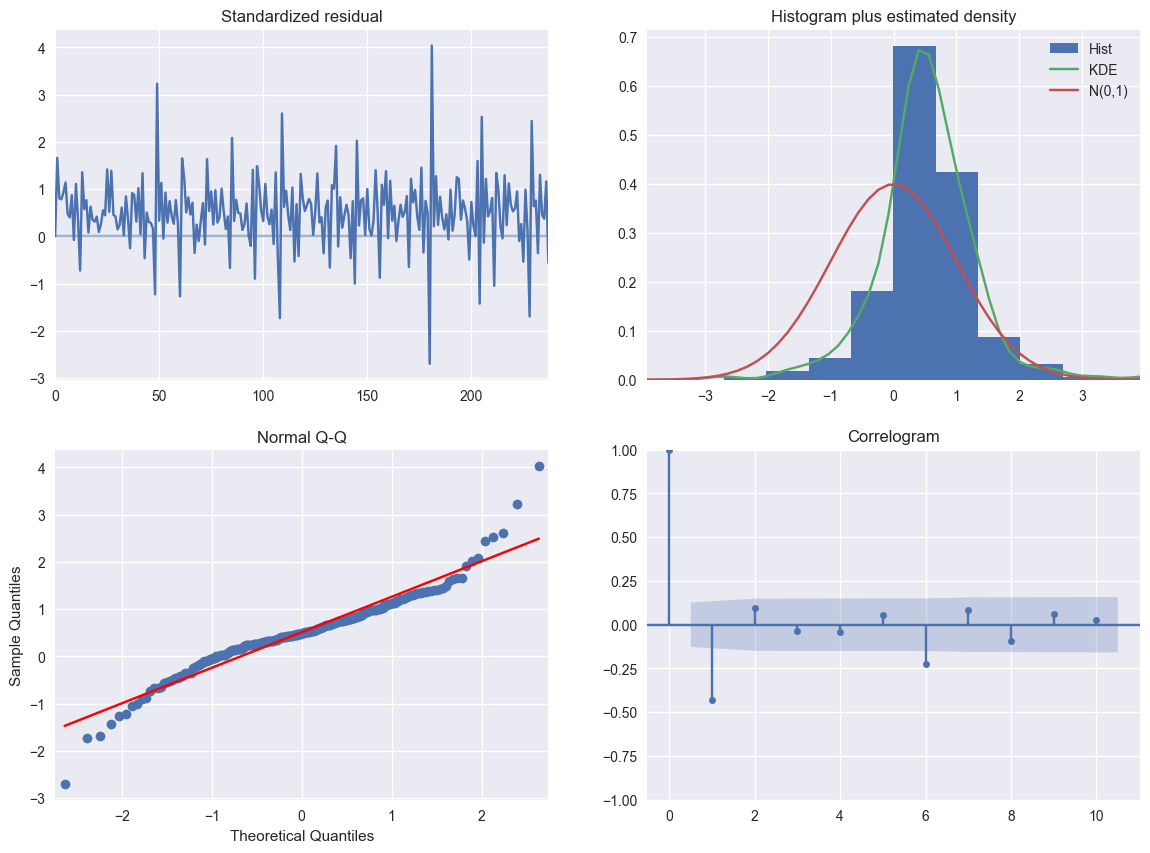

In [63]:
auto_model.plot_diagnostics(figsize=(14,10))
plt.show()

In [64]:
print(auto_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  239
Model:             SARIMAX(0, 1, 0)x(0, 0, [1], 12)   Log Likelihood                2670.074
Date:                              Thu, 04 Dec 2025   AIC                          -5334.148
Time:                                      19:57:35   BIC                          -5323.731
Sample:                                           0   HQIC                         -5329.950
                                              - 239                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -2.584e-06   4.04e-07     -6.403      0.000   -3.37e-06   -1.79e-06
ma.S.L12       0.48

## Data From 2014

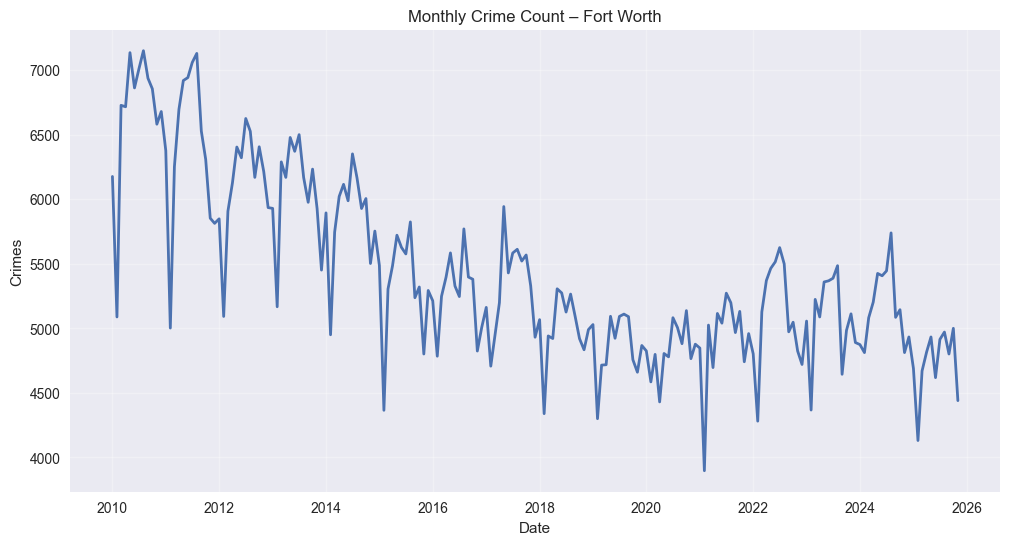

In [67]:
df3 = df2[(df2['Date'] >= '2010-01-01')]
plt.figure(figsize=(12,6))
plt.plot(df3['Date'], df3['Crime_Count'], linewidth=2)

plt.title('Monthly Crime Count – Fort Worth')
plt.xlabel('Date')
plt.ylabel('Crimes')
plt.grid(alpha=0.3)
plt.show()